# 1 · Relay races with `RelayRace`

**Use `RelayRace` when a team shares one ergometer and its rowers take turns.** The team result is one distance (timed race) or one time (distance race). Teams can differ in size and in their mix of categories.

| Your race | Class |
|---|---|
| team takes turns on **one** erg | **`RelayRace`** (this notebook) |
| individuals of different categories, one erg each | `MixedRace` → notebook 2 |
| boats (1x … 8+) with mixed crews on the water | `CrewRace` → notebook 3 |

**What you get**
* *before the race*: `handicaps()` — a staggered start (distance races) or target distances / metre credits (timed races);
* *after the race*: `results()` — the power score σ, the fraction of reference power the team sustained.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../.."))   # use the repo copy of ergrace
%matplotlib inline
import numpy as np
import pandas as pd
pd.set_option("display.precision", 4)

from ergrace import RelayRace, References

## Categories and references

Athletes are written as categories: `"Senior M"`, `"Junior W"`, `"Master F"`, or just `"M"` / `"W"` for seniors. Every category has a 2000 m reference time. The bundled defaults use the open **world records** for seniors. **Junior and master values are placeholders** (+5 % and +8 % in time); replace them with your own references (see the end of this notebook). Only the *ratios* between categories affect handicaps and rankings.

In [2]:
References.default().table()

,Category,Time 2000 m,Split /500 m,Power (W)
0,Senior M,5:34.7,1:23.7,597.4
1,Junior M,5:51.4,1:27.8,516.2
2,Master M,6:01.5,1:30.4,474.2
3,Senior W,6:21.1,1:35.3,404.7
4,Junior W,6:40.2,1:40.0,349.5
5,Master W,6:51.6,1:42.9,321.2


## A 30-minute relay (fixed time)

Five teams of three, swapping on the clock. `level=0.7` means we expect the teams to row at about 70 % of world-record power; this sets the size of the handicaps, not their order.

In [3]:
teams = {
    "Team 1": ["Junior M", "Senior W", "Senior M"],
    "Team 2": ["Junior M", "Senior W", "Senior W"],
    "Team 3": {"Senior W": 3},                      # counts work too
    "Team 4": ["Master M", "Master W", "Junior W"],
    "Team 5": {"Senior M": 2, "Junior W": 1},
}
relay = RelayRace(time="30:00", teams=teams, level=0.7)
relay.print_handicaps()


     RELAY 30:00: TARGET DISTANCES (expected level 70% of reference power)      
 Entry              Category Target Distance (m) Credit (m)
Team 4 Mas M + Jun W + Mas W                8198        831
Team 3               3 Sen W                8387        642
Team 2       Jun M + 2 Sen W                8624        405
Team 1 Jun M + Sen M + Sen W                9011         18
Team 5       2 Sen M + Jun W                9029          0



In a timed race nobody can start late, so the handicap is a **metre credit**: the distance added to a team's result. Equivalently, every team has its own target distance.

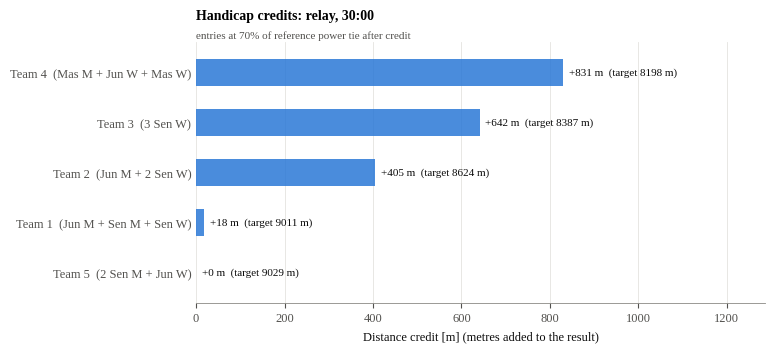

In [4]:
relay.plot_handicaps();

After the race, enter the distances on the monitors:

In [5]:
relay.record({"Team 1": 8480, "Team 2": 8120, "Team 3": 7710,
              "Team 4": 7690, "Team 5": 8590})
relay.print_results()


                    RELAY 30:00: RESULTS (Score = fraction of reference power)                    
 Rank  Entry              Category Distance (m) Split /500 m Speed Score  Score Vs Handicap (m)
    1 Team 5       2 Sen M + Jun W         8590       1:44.8      0.8447 0.6027            -439
    2 Team 2       Jun M + 2 Sen W         8120       1:50.8      0.8360 0.5844            -504
    3 Team 1 Jun M + Sen M + Sen W         8480       1:46.1      0.8356 0.5833            -531
    4 Team 4 Mas M + Jun W + Mas W         7690       1:57.0      0.8328 0.5777            -508
    5 Team 3               3 Sen W         7710       1:56.7      0.8162 0.5437            -677



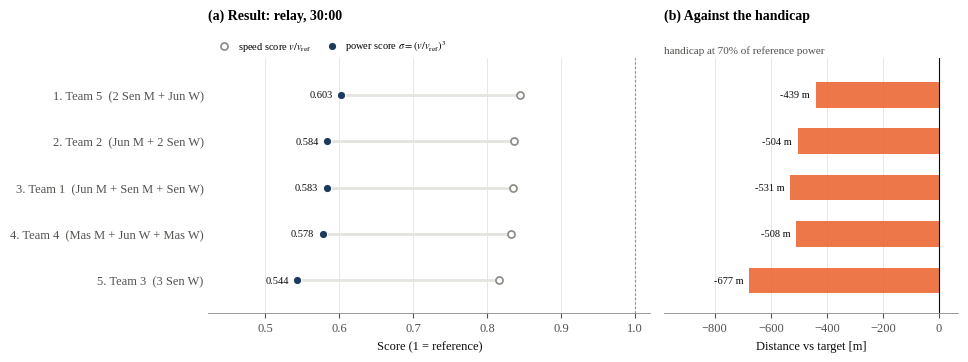

In [6]:
relay.plot_results();

**Reading the result.** *Score* σ is the fraction of reference power the team sustained, and it decides the ranking. *Speed Score* is the same information on the speed scale (σ = speed score³); a 5 % speed deficit is a 14 % power deficit. Panel (b) shows how each team did against its handicap target.

In [7]:
relay.results()

,Rank,Entry,Category,Distance (m),Time (s),Time,Split /500 m,Speed Score,Score,Target Distance (m),Vs Handicap (m)
0,1,Team 5,2 Sen M + Jun W,8590.0,1800.0,30:00.0,1:44.8,0.8447,0.6027,9029.1857,-439.1857
1,2,Team 2,Jun M + 2 Sen W,8120.0,1800.0,30:00.0,1:50.8,0.8360,0.5844,8623.7423,-503.7423
2,3,Team 1,Jun M + Sen M + Sen W,8480.0,1800.0,30:00.0,1:46.1,0.8356,0.5833,9011.3305,-531.3305
3,4,Team 4,Mas M + Jun W + Mas W,7690.0,1800.0,30:00.0,1:57.0,0.8328,0.5777,8198.4214,-508.4214
4,5,Team 3,3 Sen W,7710.0,1800.0,30:00.0,1:56.7,0.8162,0.5437,8387.4427,-677.4427


## A 3 × 1000 m relay (fixed distance): staggered start

In a distance race the handicap is a **start time**: the slowest team starts first, and the others follow so that everyone arrives together if all row at the same level. By default each rower rows one equal leg (`split="distance"`).


     RELAY 3000 m: STAGGERED START (expected level 70% of reference power)      
 Start #  Entry              Category Expected Time Start Offset
       1 Team 4 Mas M + Jun W + Mas W       11:00.7      +0:00.0
       2 Team 3               3 Sen W       10:43.8      +0:16.9
       3 Team 2       Jun M + 2 Sen W       10:27.1      +0:33.6
       4 Team 5       2 Sen M + Jun W       10:02.3      +0:58.4
       5 Team 1 Jun M + Sen M + Sen W       10:01.0      +0:59.7



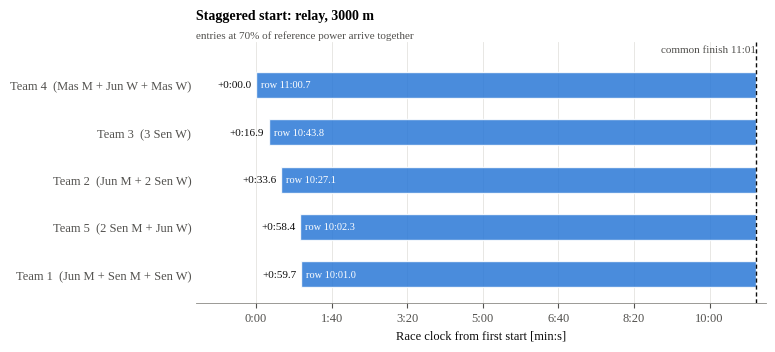

In [8]:
relay_d = RelayRace(distance=3000, teams=teams, level=0.7)
relay_d.print_handicaps()
relay_d.plot_handicaps();


                      RELAY 3000 m: RESULTS (Score = fraction of reference power)                       
 Rank  Entry              Category    Time Split /500 m Speed Score  Score  Line Order Vs Handicap (s)
    1 Team 4 Mas M + Jun W + Mas W 10:52.3       1:48.7      0.8994 0.7274           1         -0:08.4
    2 Team 5       2 Sen M + Jun W  9:55.1       1:39.2      0.8987 0.7258           2         -0:07.2
    3 Team 2       Jun M + 2 Sen W 10:20.9       1:43.5      0.8968 0.7212           3         -0:06.2
    4 Team 1 Jun M + Sen M + Sen W 10:02.4       1:40.4      0.8858 0.6950           4         +0:01.4
    5 Team 3               3 Sen W 10:47.0       1:47.8      0.8835 0.6897           5         +0:03.2



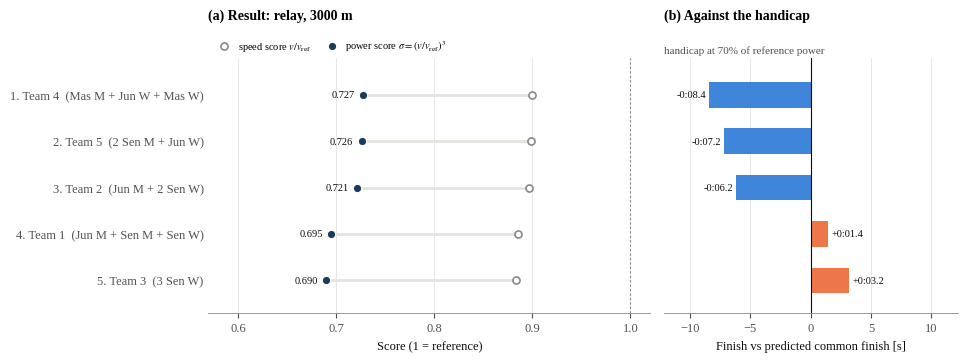

In [9]:
relay_d.record({"Team 1": "10:02.4", "Team 2": "10:20.9", "Team 3": "10:47.0",
                "Team 4": "10:52.3", "Team 5": "9:55.1"})
relay_d.print_results()
relay_d.plot_results();

*Line Order* is the order in which teams crossed the finish after the staggered start. It usually matches the σ ranking, but not exactly when teams row far from the chosen `level`.

---
## Limit cases

### 1 · A team rowing exactly at reference scores 1, whatever its mix
We take the reference distances predicted by the handicap at `level=1` and enter them as results.

In [10]:
check = RelayRace(time="30:00", teams=teams)            # level = 1
targets = check.handicaps().set_index("Entry")["Target Distance (m)"]
check.record(targets.to_dict()).results()[["Entry", "Category", "Score"]]

,Entry,Category,Score
0,Team 3,3 Sen W,1.0
1,Team 4,Mas M + Jun W + Mas W,1.0
2,Team 2,Jun M + 2 Sen W,1.0
3,Team 1,Jun M + Sen M + Sen W,1.0
4,Team 5,2 Sen M + Jun W,1.0


### 2 · How the work is shared matters for mixed teams
* `split="time"` (swap on the clock): the rowers' **distances** add, so the team reference speed is the *arithmetic* mean of their speeds.
* `split="distance"` (equal legs): their **times** add, so it is the *harmonic* mean, which is slightly slower because the slow leg takes longer.

For a single-category team both are identical.

In [11]:
rows = []
for name, members in {"mixed": ["Senior M", "Senior W", "Junior W"],
                      "all women": ["Senior W"] * 3}.items():
    for split in ("time", "distance"):
        r = RelayRace(distance=3000, teams={name: members}, split=split)
        t = r.handicaps()["Expected Time"].iloc[0]
        rows.append({"team": name, "split": split, "reference time 3000 m": t})
pd.DataFrame(rows)

,team,split,reference time 3000 m
0,mixed,time,9:14.8
1,mixed,distance,9:18.0
2,all women,time,9:31.7
3,all women,distance,9:31.7


### 3 · Teams of different sizes
Without fatigue, one senior woman rowing 30 minutes alone has the same reference as five senior women taking turns: the reference averages over the team. In reality the solo rower tires more. `fatigue=5` applies **Paul's law** (the split slows by about 5 s/500 m per doubling of the distance each rower rows), which credits smaller teams.

In [12]:
sizes = {"1 rower": ["Senior W"], "3 rowers": ["Senior W"] * 3, "5 rowers": ["Senior W"] * 5}
for f in (None, 5):
    r = RelayRace(time="30:00", teams=sizes, fatigue=f, level=0.7)
    print(f"fatigue={f}")
    print(r.handicaps()[["Entry", "Target Distance (m)", "Credit (m)"]].round(0).to_string(index=False), "\n")

fatigue=None
   Entry  Target Distance (m)  Credit (m)
 1 rower               8387.0         0.0
3 rowers               8387.0         0.0
5 rowers               8387.0         0.0 

fatigue=5
   Entry  Target Distance (m)  Credit (m)
 1 rower               7505.0       919.0
3 rowers               8109.0       315.0
5 rowers               8424.0         0.0 



### 4 · `level` changes the size of the handicaps, not their order

In [13]:
for level in (1.0, 0.7, 0.5):
    hc = RelayRace(distance=3000, teams=teams, level=level).handicaps()
    print(f"level {level:.1f}: ", ", ".join(f"{e} {o}" for e, o in zip(hc["Entry"], hc["Start Offset"])))

level 1.0:  Team 4 +0:00.0, Team 3 +0:15.0, Team 2 +0:29.8, Team 5 +0:51.9, Team 1 +0:53.0
level 0.7:  Team 4 +0:00.0, Team 3 +0:16.9, Team 2 +0:33.6, Team 5 +0:58.4, Team 1 +0:59.7
level 0.5:  Team 4 +0:00.0, Team 3 +0:18.9, Team 2 +0:37.6, Team 5 +1:05.3, Team 1 +1:06.8


### 5 · Consistency with the RRC 2026 report
The men/women relay from the paper (30 min, 2000 m world records, swap on the clock) gives the same scores, e.g. σ = 0.8033 for Chalmers 1 (2M/3F, 9268 m).

In [14]:
rrc = RelayRace(time="30:00", teams={
    "Chalmers 1": {"Senior M": 2, "Senior W": 3},
    "CTH-GU": {"Senior M": 3, "Senior W": 2},
    "Göteborgs RK": {"Senior W": 5}})
rrc.record({"Chalmers 1": 9268, "CTH-GU": 9511, "Göteborgs RK": 8575})
rrc.results()[["Rank", "Entry", "Category", "Distance (m)", "Score"]]

,Rank,Entry,Category,Distance (m),Score
0,1,Chalmers 1,2 Sen M + 3 Sen W,9268.0,0.8033
1,2,CTH-GU,3 Sen M + 2 Sen W,9511.0,0.8031
2,3,Göteborgs RK,5 Sen W,8575.0,0.7480


## Your own references
Replace the placeholders by the references you want to use (e.g. club benchmarks or Concept2 age-group records):

In [15]:
club = References.default().updated({"Junior M": "6:05.0", "Junior W": "7:02.0",
                                     "Master M": "6:20.0", "Master W": "7:20.0"})
RelayRace(time="30:00", teams=teams, references=club, level=0.7).print_handicaps()


     RELAY 30:00: TARGET DISTANCES (expected level 70% of reference power)      
 Entry              Category Target Distance (m) Credit (m)
Team 4 Mas M + Jun W + Mas W                7750       1148
Team 3               3 Sen W                8387        511
Team 2       Jun M + 2 Sen W                8511        388
Team 5       2 Sen M + Jun W                8892          7
Team 1 Jun M + Sen M + Sen W                8898          0

